# 01 — Análise Exploratória de Dados (EDA)

Entende a estrutura do dataset, calcula as métricas de negócio (ROI, CPA, taxa de conversão) e documenta as distribuições e relações relevantes para o modelo what-if.

**Entrada:** `data/raw/conversion_data.csv`  
**Saída:** apenas visualizações e insights — nenhum arquivo é salvo aqui.

In [14]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

In [15]:
RAW = Path("../data/raw")
df  = pd.read_csv(RAW / "conversion_data.csv")

# Parâmetro de negócio: valor médio por pedido (em USD)
AVG_ORDER_VALUE = 50.0

print(f"Registros: {len(df)} | Colunas: {df.shape[1]}")
df.head()

Registros: 1143 | Colunas: 11


,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,impressions,clicks,spent,total_conversion,approved_conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1


## 1. Qualidade dos dados

In [16]:
print("=== Nulos por coluna ===")
print(df.isnull().sum())

print("\n=== Duplicatas ===")
print(df.duplicated().sum())

print("\n=== Tipos ===")
print(df.dtypes)

=== Nulos por coluna ===
ad_id                  0
xyz_campaign_id        0
fb_campaign_id         0
age                    0
gender                 0
interest               0
impressions            0
clicks                 0
spent                  0
total_conversion       0
approved_conversion    0
dtype: int64

=== Duplicatas ===
0

=== Tipos ===
ad_id                    int64
xyz_campaign_id          int64
fb_campaign_id           int64
age                        str
gender                     str
interest                 int64
impressions              int64
clicks                   int64
spent                  float64
total_conversion         int64
approved_conversion      int64
dtype: object


In [17]:
print("Campanhas (xyz_campaign_id):")
print(df["xyz_campaign_id"].value_counts())

Campanhas (xyz_campaign_id):
xyz_campaign_id
1178    625
936     464
916      54
Name: count, dtype: int64


## 2. Cálculo das métricas de negócio

| Métrica | Fórmula |
|---|---|
| Receita estimada | `approved_conversion × avg_order_value` |
| ROI | `(receita − spent) / spent` |
| Taxa de conversão | `approved_conversion / clicks` |
| CPA | `spent / approved_conversion` |

In [18]:
df["revenue"]         = df["approved_conversion"] * AVG_ORDER_VALUE
df["roi"]             = (df["revenue"] - df["spent"]) / df["spent"].replace(0, np.nan)
df["conversion_rate"] = df["approved_conversion"] / df["clicks"].replace(0, np.nan)
df["cpa"]             = df["spent"] / df["approved_conversion"].replace(0, np.nan)

print(df[["spent", "revenue", "roi", "conversion_rate", "cpa"]].describe().round(3))

          spent   revenue      roi  conversion_rate      cpa
count  1143.000  1143.000  936.000          936.000  584.000
mean     51.361    47.200    3.250            0.109   40.553
std      86.908    86.885   13.386            0.247   54.273
min       0.000     0.000   -1.000            0.000    0.000
25%       1.480     0.000   -1.000            0.000    3.067
50%      12.370    50.000   -0.607            0.013   22.847
75%      60.025    50.000    0.991            0.067   54.005
max     639.950  1050.000  276.778            2.000  352.450


## 3. Estatísticas descritivas por campanha

In [19]:
camp_stats = df.groupby("xyz_campaign_id").agg(
    total_spent      = ("spent",               "sum"),
    total_conversoes = ("approved_conversion",  "sum"),
    roi_medio        = ("roi",                  "mean"),
    conv_rate_media  = ("conversion_rate",      "mean"),
    cpa_medio        = ("cpa",                  "mean"),
    n_anuncios       = ("ad_id",                "count"),
).round(3)

print(camp_stats)

                 total_spent  total_conversoes  roi_medio  conv_rate_media  \
xyz_campaign_id                                                              
916                   149.71                24      8.714            0.257   
936                  2893.37               183      8.146            0.212   
1178                55662.15               872      0.637            0.052   

                 cpa_medio  n_anuncios  
xyz_campaign_id                         
916                  3.142          54  
936                  5.496         464  
1178                58.407         625  


## 4. Distribuições univariadas

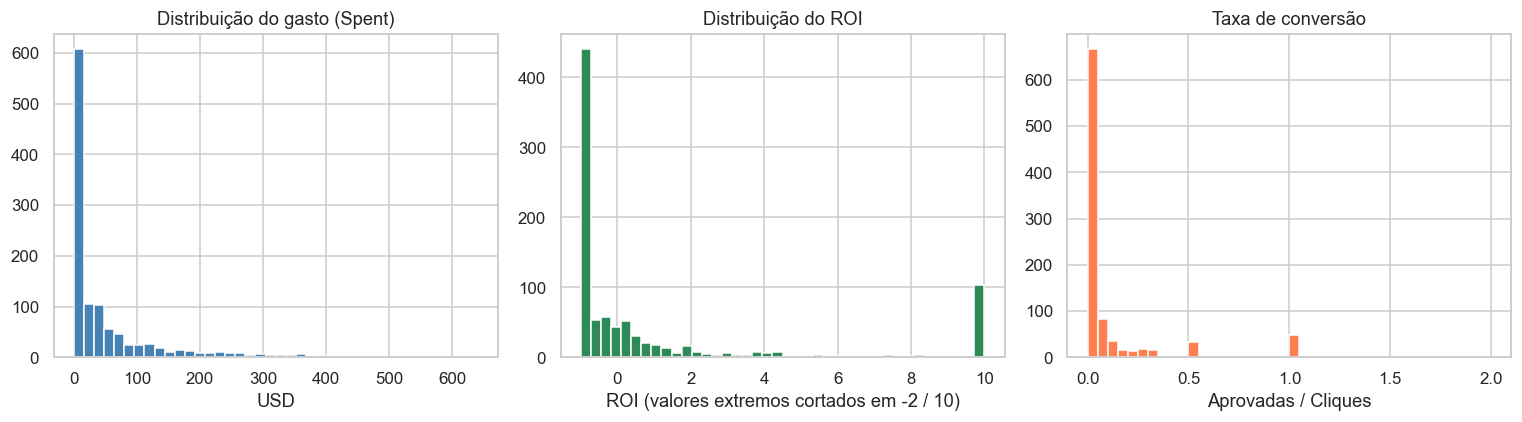

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df["spent"].dropna(), bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Distribuição do gasto (Spent)")
axes[0].set_xlabel("USD")

axes[1].hist(df["roi"].dropna().clip(-2, 10), bins=40, color="seagreen", edgecolor="white")
axes[1].set_title("Distribuição do ROI")
axes[1].set_xlabel("ROI (valores extremos cortados em -2 / 10)")

axes[2].hist(df["conversion_rate"].dropna(), bins=40, color="coral", edgecolor="white")
axes[2].set_title("Taxa de conversão")
axes[2].set_xlabel("Aprovadas / Cliques")

plt.tight_layout()
plt.show()

## 5. Relação investimento vs. conversões

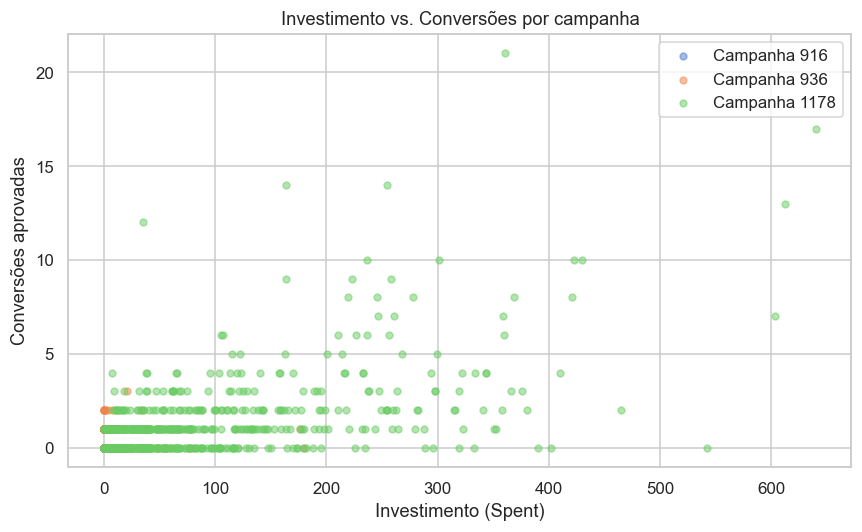

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

for cid, grupo in df.groupby("xyz_campaign_id"):
    ax.scatter(grupo["spent"], grupo["approved_conversion"],
               alpha=0.5, s=20, label=f"Campanha {cid}")

ax.set_xlabel("Investimento (Spent)")
ax.set_ylabel("Conversões aprovadas")
ax.set_title("Investimento vs. Conversões por campanha")
ax.legend()
plt.tight_layout()
plt.show()

## 6. ROI por campanha (boxplot)

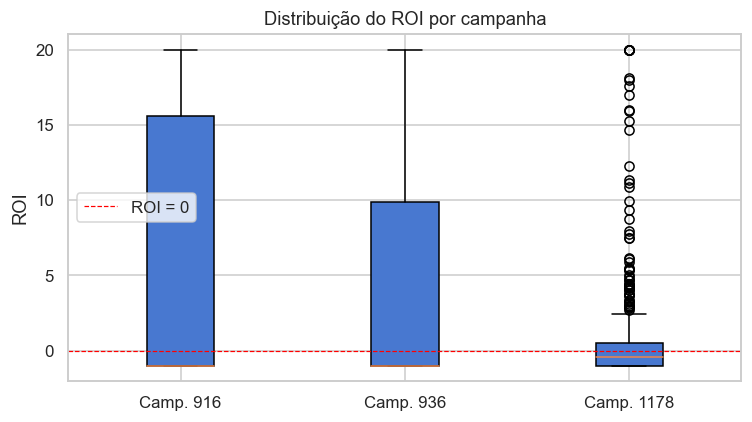

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))

campanhas = sorted(df["xyz_campaign_id"].unique())
dados = [df[df["xyz_campaign_id"] == c]["roi"].dropna().clip(-2, 20) for c in campanhas]

ax.boxplot(dados, labels=[f"Camp. {c}" for c in campanhas], patch_artist=True)
ax.axhline(0, color="red", linewidth=0.8, linestyle="--", label="ROI = 0")
ax.set_ylabel("ROI")
ax.set_title("Distribuição do ROI por campanha")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Segmentação por faixa etária e gênero

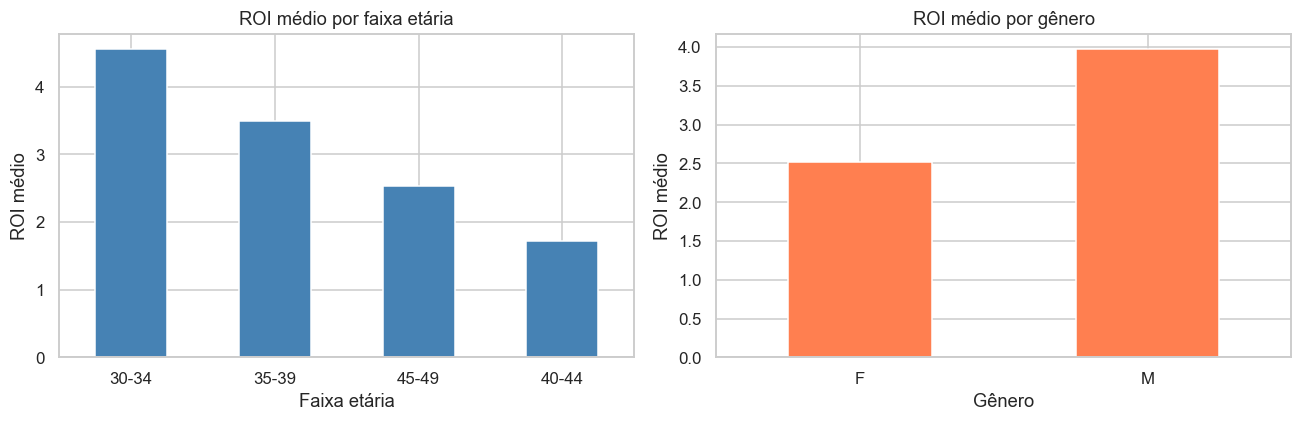

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

roi_age = df.groupby("age")["roi"].mean().sort_values(ascending=False)
roi_age.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("ROI médio por faixa etária")
axes[0].set_xlabel("Faixa etária")
axes[0].set_ylabel("ROI médio")
axes[0].tick_params(axis="x", rotation=0)

roi_gender = df.groupby("gender")["roi"].mean()
roi_gender.plot(kind="bar", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("ROI médio por gênero")
axes[1].set_xlabel("Gênero")
axes[1].set_ylabel("ROI médio")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 8. Correlação entre variáveis numéricas

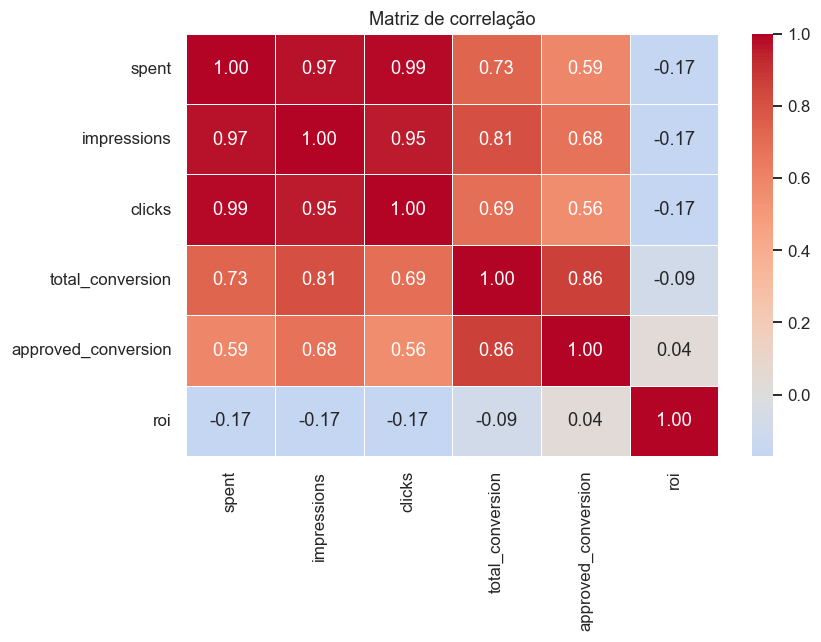

In [24]:
numericas = ["spent", "impressions", "clicks", "total_conversion", "approved_conversion", "roi"]
corr = df[numericas].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlação")
plt.tight_layout()
plt.show()

## 9. Identificação de outliers

Anúncios com gasto alto mas zero conversões aprovadas podem distorcer o modelo.

In [25]:
outliers = df[
    (df["spent"] > df["spent"].quantile(0.90)) &
    (df["approved_conversion"] == 0)
]

print(f"Anúncios com gasto no top 10% e zero conversões: {len(outliers)}")
print(f"Total gasto nesses anúncios: {outliers['spent'].sum():.2f}")
outliers[["ad_id", "xyz_campaign_id", "spent", "clicks", "approved_conversion"]].head(10)

Anúncios com gasto no top 10% e zero conversões: 18
Total gasto nesses anúncios: 4636.73


,ad_id,xyz_campaign_id,spent,clicks,approved_conversion
207,776325,936,180.220001,114,0
793,1121661,1178,181.720001,105,0
856,1121803,1178,169.919997,119,0
904,1121894,1178,173.760000,124,0
969,1122112,1178,390.259999,276,0
975,1122127,1178,288.330003,194,0
996,1122197,1178,234.939999,163,0
997,1122200,1178,195.079999,139,0
999,1122202,1178,295.549996,202,0
1000,1122203,1178,226.030001,164,0


## 10. Sumário

In [26]:
print("=== Resumo da EDA ===")
print(f"Total de anúncios        : {len(df)}")
print(f"Campanhas                : {sorted(df['xyz_campaign_id'].unique())}")
print(f"Gasto total              : {df['spent'].sum():,.2f}")
print(f"Conversões totais        : {int(df['approved_conversion'].sum())}")
print(f"Taxa de conversão média  : {df['conversion_rate'].mean():.4f}")
print(f"ROI mediano              : {df['roi'].median():.4f}")
print(f"Anúncios sem conversão   : {(df['approved_conversion'] == 0).sum()}")

=== Resumo da EDA ===
Total de anúncios        : 1143
Campanhas                : [916, 936, 1178]
Gasto total              : 58,705.23
Conversões totais        : 1079
Taxa de conversão média  : 0.1090
ROI mediano              : -0.6071
Anúncios sem conversão   : 559
